# Superstore Sales Analysis - Business Intelligence Report

## Objective
Analyze 4 years of retail sales data (2014-2017) to identify profit drivers,
loss-making areas, and actionable business recommendations.

## Dataset
- 9,994 orders across 4 years
- 21 features including sales, profit, discount, category, region, segment
- Total Revenue: $2.29M | Total Profit: $286k | Overall Margin: 12%

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Piyush Kumar\Desktop\lessgo\projects\sample-superstore-sales-project\data\Sample - Superstore.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 3 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic stats:")
print(df[['Sales', 'Profit', 'Discount', 'Quantity']].describe().round(2))

Shape: (9994, 21)

Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64



In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100

print("Date columns fixed!")
print("\nYears in dataset:", sorted(df['Order Year'].unique()))
print("Avg shipping days:", df['Shipping Days'].mean().round(1))
print("\nOverall Profit Margin:", df['Profit Margin %'].mean().round(2), "%")

Date columns fixed!

Years in dataset: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Avg shipping days: 4.0

Overall Profit Margin: 12.03 %


## Finding 1: Discounts Above 20% Are Loss-Making

The single biggest threat to profitability is aggressive discounting.
Any discount above 20% results in negative profit margin on average.
Orders with 50-80% discounts lose more money than they generate in revenue.

                 Total_Sales  Total_Profit  Avg_Margin  Order_Count
Category                                                           
Technology         836154.03     145454.95       15.61         1847
Furniture          741999.80      18451.27        3.88         2121
Office Supplies    719047.03     122490.80       13.80         6026


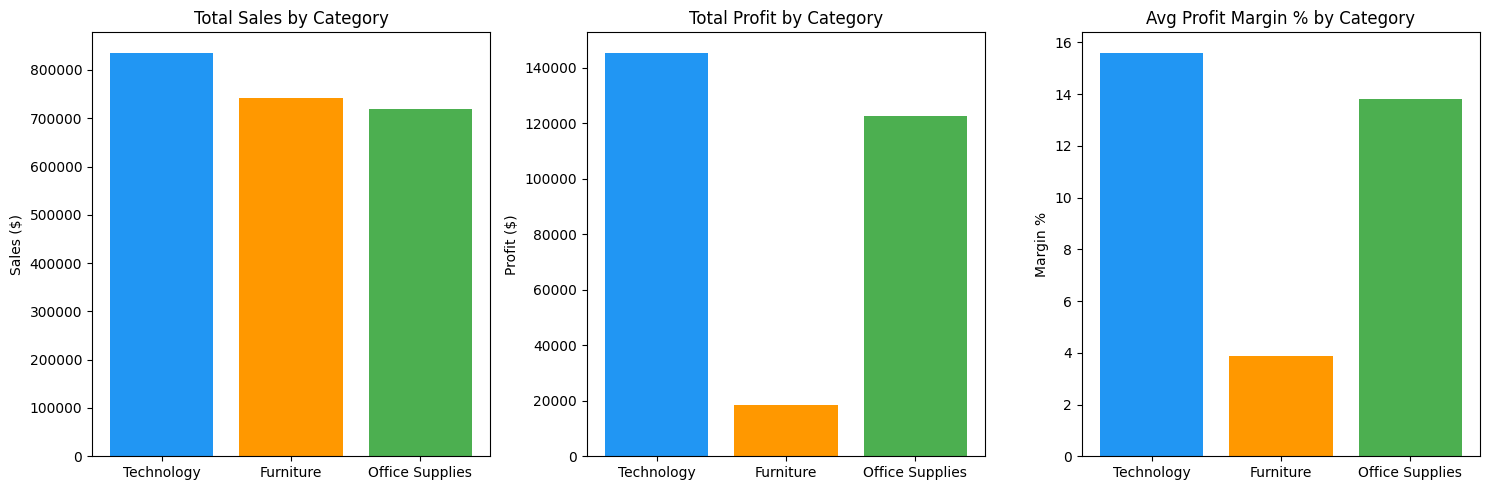

In [6]:
category_analysis = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin %', 'mean'),
    Order_Count=('Order ID', 'count')
).round(2).sort_values('Total_Sales', ascending=False)

print(category_analysis)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(category_analysis.index, category_analysis['Total_Sales'], color=['#2196F3', '#FF9800', '#4CAF50'])
axes[0].set_title('Total Sales by Category')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(category_analysis.index, category_analysis['Total_Profit'], color=['#2196F3', '#FF9800', '#4CAF50'])
axes[1].set_title('Total Profit by Category')
axes[1].set_ylabel('Profit ($)')

axes[2].bar(category_analysis.index, category_analysis['Avg_Margin'], color=['#2196F3', '#FF9800', '#4CAF50'])
axes[2].set_title('Avg Profit Margin % by Category')
axes[2].set_ylabel('Margin %')

plt.tight_layout()
plt.show()

## Finding 2: Furniture Category Is Broken

Furniture generates $742k in sales (2nd highest) but only $18k profit.
The root cause is heavy discounting on Tables (26% avg discount) and
Bookcases (21% avg discount), both of which are net loss-making sub-categories.

In [7]:
subcategory_analysis = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Margin=('Profit Margin %', 'mean')
).round(2).sort_values('Total_Profit', ascending=True)

print(subcategory_analysis)

                              Total_Sales  Total_Profit  Avg_Discount  \
Category        Sub-Category                                            
Furniture       Tables          206965.53     -17725.48          0.26   
                Bookcases       114880.00      -3472.56          0.21   
Office Supplies Supplies         46673.54      -1189.10          0.08   
                Fasteners         3024.28        949.52          0.08   
Technology      Machines        189238.63       3384.76          0.31   
Office Supplies Labels           12486.31       5546.25          0.07   
                Art              27118.79       6527.79          0.07   
                Envelopes        16476.40       6964.18          0.08   
Furniture       Furnishings      91705.16      13059.14          0.14   
Office Supplies Appliances      107532.16      18138.01          0.17   
                Storage         223843.61      21278.83          0.07   
Furniture       Chairs          328449.10      2659

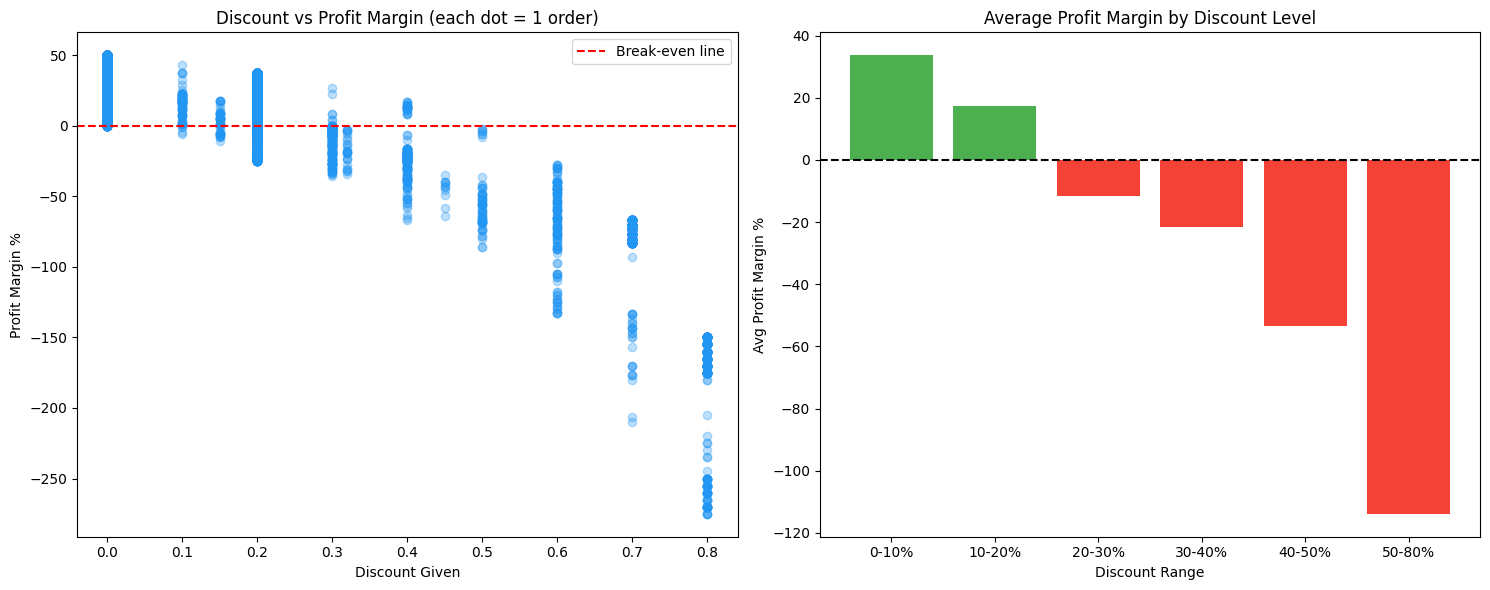

Avg Profit Margin by Discount Level:
Discount
0-10%      33.66
10-20%     17.48
20-30%    -11.55
30-40%    -21.69
40-50%    -53.56
50-80%   -113.88
Name: Profit Margin %, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(df['Discount'], df['Profit Margin %'], alpha=0.3, color='#2196F3')
axes[0].axhline(y=0, color='red', linestyle='--', label='Break-even line')
axes[0].set_xlabel('Discount Given')
axes[0].set_ylabel('Profit Margin %')
axes[0].set_title('Discount vs Profit Margin (each dot = 1 order)')
axes[0].legend()

discount_bins = pd.cut(df['Discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8], 
                        labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-80%'],
                        include_lowest=True)
discount_profit = df.groupby(discount_bins, observed=True)['Profit Margin %'].mean().round(2)

axes[1].bar(discount_profit.index, discount_profit.values, 
            color=['#4CAF50' if x > 0 else '#F44336' for x in discount_profit.values])
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('Discount Range')
axes[1].set_ylabel('Avg Profit Margin %')
axes[1].set_title('Average Profit Margin by Discount Level')

plt.tight_layout()
plt.show()

print("Avg Profit Margin by Discount Level:")
print(discount_profit)

In [10]:
region_analysis = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Margin=('Profit Margin %', 'mean')
).round(2).sort_values('Total_Profit', ascending=False)

print("=== REGIONAL PERFORMANCE ===")
print(region_analysis)

segment_analysis = df.groupby('Segment').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Avg_Margin=('Profit Margin %', 'mean')
).round(2).sort_values('Total_Profit', ascending=False)

print("\n=== SEGMENT PERFORMANCE ===")
print(segment_analysis)

=== REGIONAL PERFORMANCE ===
         Total_Sales  Total_Profit  Avg_Discount  Avg_Margin
Region                                                      
West       725457.82     108418.45          0.11       21.95
East       678781.24      91522.78          0.15       16.72
South      391721.90      46749.43          0.15       16.35
Central    501239.89      39706.36          0.24      -10.41

=== SEGMENT PERFORMANCE ===
             Total_Sales  Total_Profit  Avg_Discount  Avg_Margin
Segment                                                         
Consumer      1161401.34     134119.21          0.16       11.20
Corporate      706146.37      91979.13          0.16       12.12
Home Office    429653.15      60298.68          0.15       14.29


=== YEARLY TRENDS ===
            Total_Sales  Total_Profit  Avg_Margin  Order_Count
Order Year                                                    
2014          484247.50      49543.97       11.81         1993
2015          470532.51      61618.60       11.76         2102
2016          609205.60      81795.17       12.98         2587
2017          733215.26      93439.27       11.60         3312


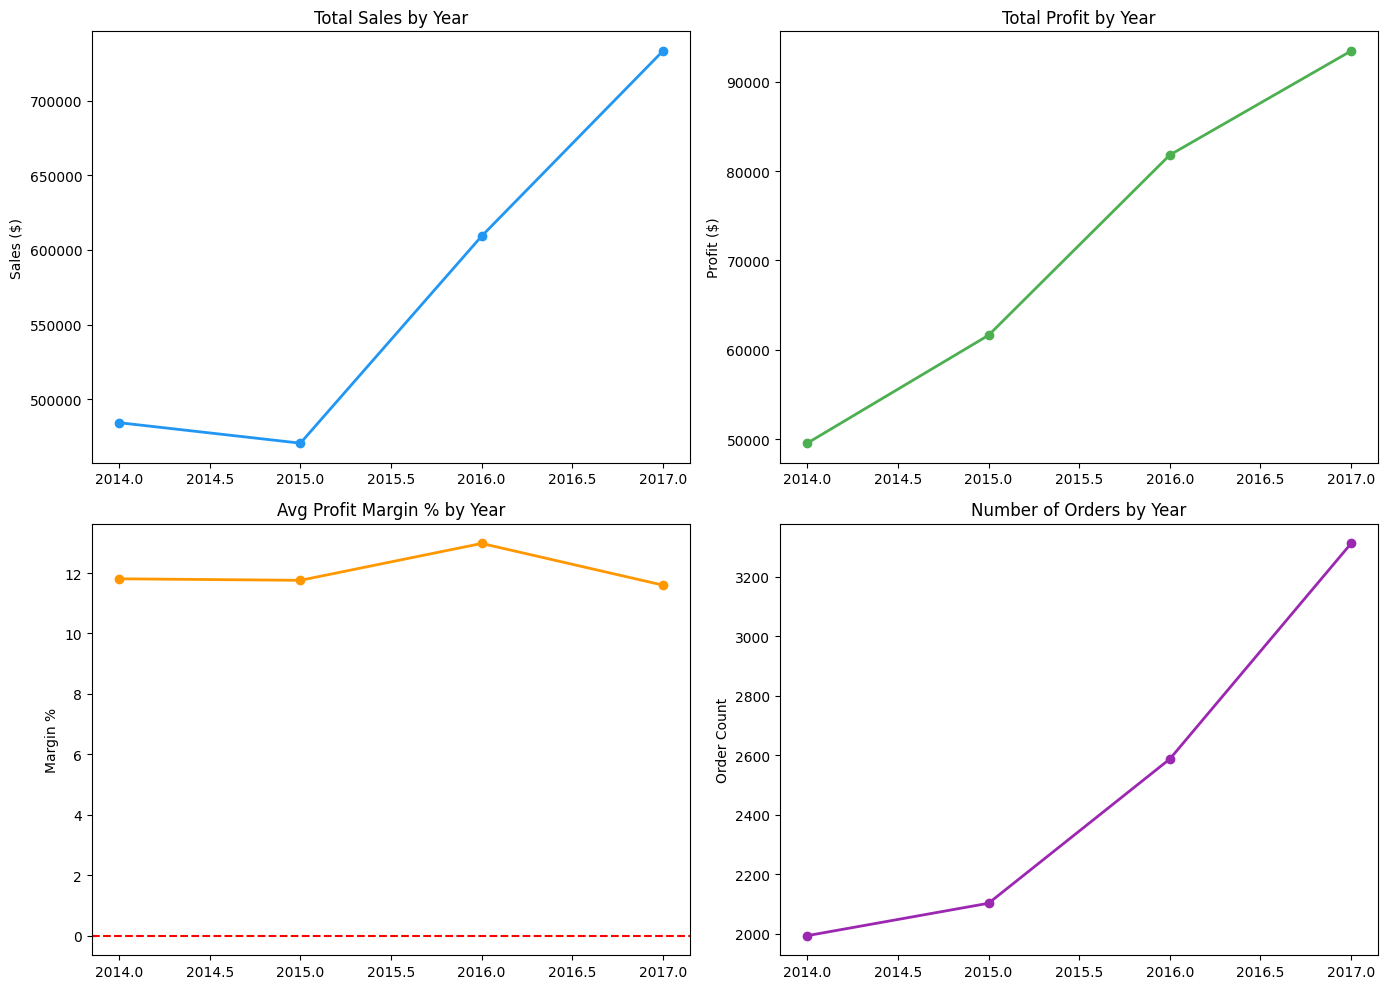

In [11]:
yearly = df.groupby('Order Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin %', 'mean'),
    Order_Count=('Order ID', 'count')
).round(2)

print("=== YEARLY TRENDS ===")
print(yearly)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(yearly.index, yearly['Total_Sales'], marker='o', color='#2196F3', linewidth=2)
axes[0,0].set_title('Total Sales by Year')
axes[0,0].set_ylabel('Sales ($)')

axes[0,1].plot(yearly.index, yearly['Total_Profit'], marker='o', color='#4CAF50', linewidth=2)
axes[0,1].set_title('Total Profit by Year')
axes[0,1].set_ylabel('Profit ($)')

axes[1,0].plot(yearly.index, yearly['Avg_Margin'], marker='o', color='#FF9800', linewidth=2)
axes[1,0].axhline(y=0, color='red', linestyle='--')
axes[1,0].set_title('Avg Profit Margin % by Year')
axes[1,0].set_ylabel('Margin %')

axes[1,1].plot(yearly.index, yearly['Order_Count'], marker='o', color='#9C27B0', linewidth=2)
axes[1,1].set_title('Number of Orders by Year')
axes[1,1].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

=== MONTHLY TRENDS ===
     Total_Sales  Total_Profit  Order_Count
Jan     94924.84       9134.45          381
Feb     59751.25      10294.61          300
Mar    205005.49      28594.69          696
Apr    137762.13      11587.44          668
May    155028.81      22411.31          735
Jun    152718.68      21285.80          717
Jul    147238.10      13832.66          710
Aug    159044.06      21776.94          706
Sep    307649.95      36857.48         1383
Oct    200322.98      31784.04          819
Nov    352461.07      35468.43         1471
Dec    325293.50      43369.19         1408


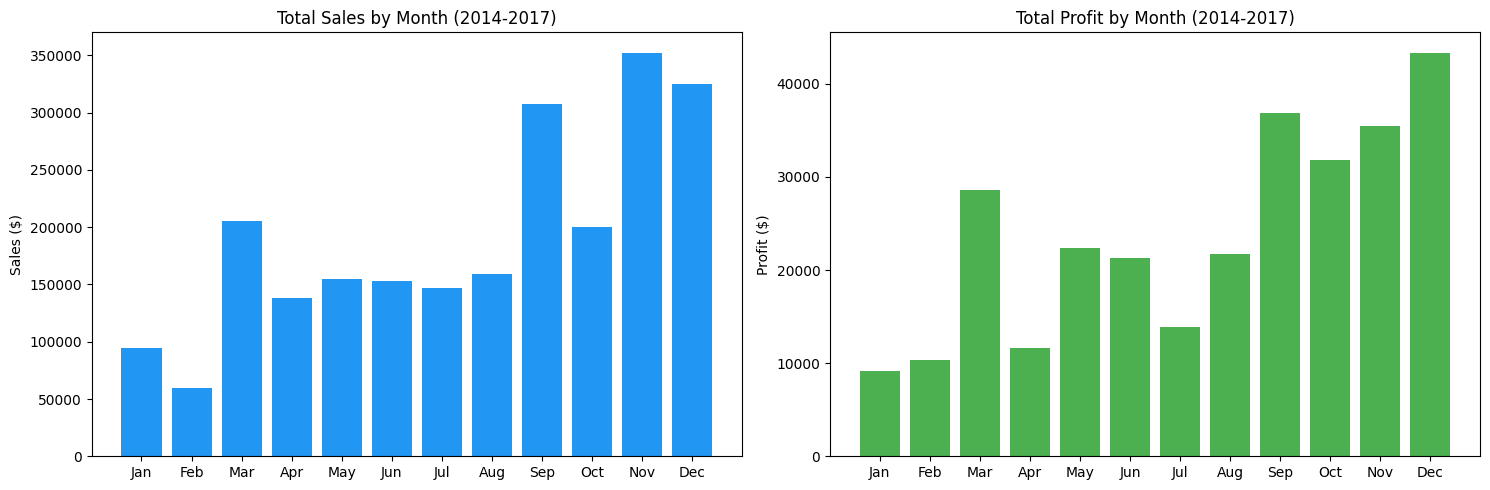

In [12]:
monthly = df.groupby('Order Month').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'count')
).round(2)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly.index = month_names

print("=== MONTHLY TRENDS ===")
print(monthly)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(monthly.index, monthly['Total_Sales'], color='#2196F3')
axes[0].set_title('Total Sales by Month (2014-2017)')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(monthly.index, monthly['Total_Profit'], 
            color=['#F44336' if x < 0 else '#4CAF50' for x in monthly['Total_Profit']])
axes[1].set_title('Total Profit by Month (2014-2017)')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()

## Finding 3: Central Region Requires Immediate Intervention

Central is the only region with negative profit margin (-10.4%).
Its average discount of 24% is significantly higher than other regions (11-15%).
The discount policy in Central is directly responsible for profit destruction.

In [13]:
print("=" * 55)
print("SUPERSTORE SALES ANALYSIS - KEY FINDINGS")
print("=" * 55)

print("\n1. OVERALL BUSINESS HEALTH")
print(f"   Total Revenue (2014-2017): ${df['Sales'].sum():,.0f}")
print(f"   Total Profit: ${df['Profit'].sum():,.0f}")
print(f"   Overall Margin: {df['Profit Margin %'].mean():.1f}%")
print(f"   Total Orders: {len(df):,}")

print("\n2. DISCOUNT IS THE #1 PROFIT KILLER")
print("   0-10% discount  → +33.7% margin")
print("   10-20% discount → +17.5% margin")
print("   20-30% discount → -11.6% margin (loss)")
print("   50-80% discount → -113.9% margin (severe loss)")

print("\n3. FURNITURE IS BROKEN")
cat = df.groupby('Category')['Profit'].sum()
print(f"   Technology profit:      ${cat['Technology']:>10,.0f}")
print(f"   Office Supplies profit: ${cat['Office Supplies']:>10,.0f}")
print(f"   Furniture profit:       ${cat['Furniture']:>10,.0f}")
print("   Tables sub-category alone: -$17,725 loss")

print("\n4. CENTRAL REGION NEEDS INTERVENTION")
reg = df.groupby('Region').agg({'Profit Margin %': 'mean', 'Discount': 'mean'}).round(2)
for region, row in reg.iterrows():
    print(f"   {region:<10} Margin: {row['Profit Margin %']:>7.1f}%  Avg Discount: {row['Discount']:.0%}")

print("\n5. SEASONALITY")
print("   Peak months: Sep, Nov, Dec (Q4 = highest sales + profit)")
print("   Dead months: Jan, Feb (lowest sales of year)")
print("   Recommendation: Focus inventory and staffing on Q4")

print("\n6. BUSINESS IS GROWING BUT NOT IMPROVING")
print("   Orders grew 66% from 2014 to 2017")
print("   But profit margin stayed flat at ~12% all 4 years")
print("   Growth is volume-driven, not efficiency-driven")

SUPERSTORE SALES ANALYSIS - KEY FINDINGS

1. OVERALL BUSINESS HEALTH
   Total Revenue (2014-2017): $2,297,201
   Total Profit: $286,397
   Overall Margin: 12.0%
   Total Orders: 9,994

2. DISCOUNT IS THE #1 PROFIT KILLER
   0-10% discount  → +33.7% margin
   10-20% discount → +17.5% margin
   20-30% discount → -11.6% margin (loss)
   50-80% discount → -113.9% margin (severe loss)

3. FURNITURE IS BROKEN
   Technology profit:      $   145,455
   Office Supplies profit: $   122,491
   Furniture profit:       $    18,451
   Tables sub-category alone: -$17,725 loss

4. CENTRAL REGION NEEDS INTERVENTION
   Central    Margin:   -10.4%  Avg Discount: 24%
   East       Margin:    16.7%  Avg Discount: 15%
   South      Margin:    16.4%  Avg Discount: 15%
   West       Margin:    21.9%  Avg Discount: 11%

5. SEASONALITY
   Peak months: Sep, Nov, Dec (Q4 = highest sales + profit)
   Dead months: Jan, Feb (lowest sales of year)
   Recommendation: Focus inventory and staffing on Q4

6. BUSINESS IS 

## Business Recommendations

| Priority | Action | Expected Impact |
|----------|--------|----------------|
| HIGH | Cap all discounts at 20% company-wide | Eliminate loss-making orders |
| HIGH | Audit Central region discount approvals | Fix -10.4% margin |
| MEDIUM | Review Tables and Bookcases pricing | Stop -$17k annual loss |
| MEDIUM | Increase Technology investment | Highest margin category at 15.6% |
| LOW | Run Q1 promotions (Jan-Feb) | Reduce seasonal revenue dip |

## Key Takeaway
The business is growing (66% more orders in 4 years) but not becoming more
profitable (margin flat at 12%). The path to higher profitability is not more
sales — it is fixing the discount policy, especially in Furniture and Central region.